### 🚀 NEO Classification Model

This notebook focuses on preparing data and building a classification model to identify hazardous Near-Earth Objects. We use 'diameters' from asteroid complete dataset and merged it with NEO cleaned dataset and applyied exploratory data analysis (EDA).

---

#### 📦 Imports
We import necessary packages for regression modeling, visualization, preprocessing, and evaluation.

In [1]:
import pandas as pd
import numpy as np

# Regression models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Model evaluation & tuning
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, auc
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#### 📑 Load Completed Asteroid and Cleaned NEO Dataset
We extract 'diameter' from asteroid dataset and merge it into neo to make a strong classification model.

In [2]:
ast = pd.read_csv('data/asteroid_complete.csv', index_col="full_name")
neo = pd.read_csv('data/neo_cleaned.csv',index_col="name")
print(neo.shape)

(27423, 5)


#### Merging datasets

In [3]:
# 1. Extract numeric ID from both ast and neo indexes
ast = ast.copy()
neo = neo.copy()

# Ensure indexes are reset so we can extract from them
ast = ast.reset_index()
neo = neo.reset_index()

# Extract numeric ID from name (e.g., '433 Eros' → '433')
ast['name_id'] = ast['full_name'].str.extract(r'^(\d+)')
neo['name_id'] = neo['name'].str.extract(r'^(\d+)')

# Drop duplicate numeric IDs from ast to avoid many-to-one issues
ast_dedup = ast.drop_duplicates(subset='name_id')

# 2. Merge using numeric ID (first priority)
neo = neo.merge(
    ast_dedup[['name_id', 'diameter']],
    on='name_id',
    how='left'
)

# 3. OPTIONAL fallback: merge using full name if diameter is still missing
# First, build a mapping from ast
ast_fullname_map = ast.set_index('full_name')['diameter']

# Fill missing values using name match
neo['diameter'] = neo['diameter'].fillna(neo['name'].map(ast_fullname_map))

# Dropping "name_id"
neo.drop(columns='name_id', inplace=True)

# Setting "name" column as an index
neo.set_index('name', inplace=True)

# 4. Check how many matches you got
print(f"Diameters assigned: {neo['diameter'].notna().sum()} / {len(neo)}")


Diameters assigned: 27098 / 27423


In [4]:
# Checking for missing values
neo['diameter'].isna().sum()

325

In [5]:
# Dropping rows with missing entries
neo = neo[neo['diameter'].notna()].copy()
neo.shape   # 325 rows dropped

(27098, 6)

In [6]:
# Calculate missing value count and percentage
missing_count = neo.isna().sum()
missing_percentage = neo.isna().mean() * 100

# Create list of (column, missing count, percentage)
missing_info = [
    (col, missing_count[col], missing_percentage[col])
    for col in neo.columns
]

# Sort by missing count
missing_info.sort(key=lambda x: x[1], reverse=True)

# Print columns with most missing data
print(f"{'':<20} {'Missing Count':<15} {'Missing %':<15} {'Available count'}")
for col, count, percent in missing_info:
    available_count = neo.shape[0] -count
    print(f"{col:<20} {count:<15} {percent:.4f} %{'':<10} {available_count:<15}")

                     Missing Count   Missing %       Available count
absolute_magnitude   0               0.0000 %           27098          
hazardous            0               0.0000 %           27098          
relative_velocity_mean 0               0.0000 %           27098          
miss_distance_mean   0               0.0000 %           27098          
est_diameter_mean    0               0.0000 %           27098          
diameter             0               0.0000 %           27098          


In [7]:
# Save dataset as a csv file for last modelling
neo.to_csv("data/neo_complete.csv",index=True)

### Classification model

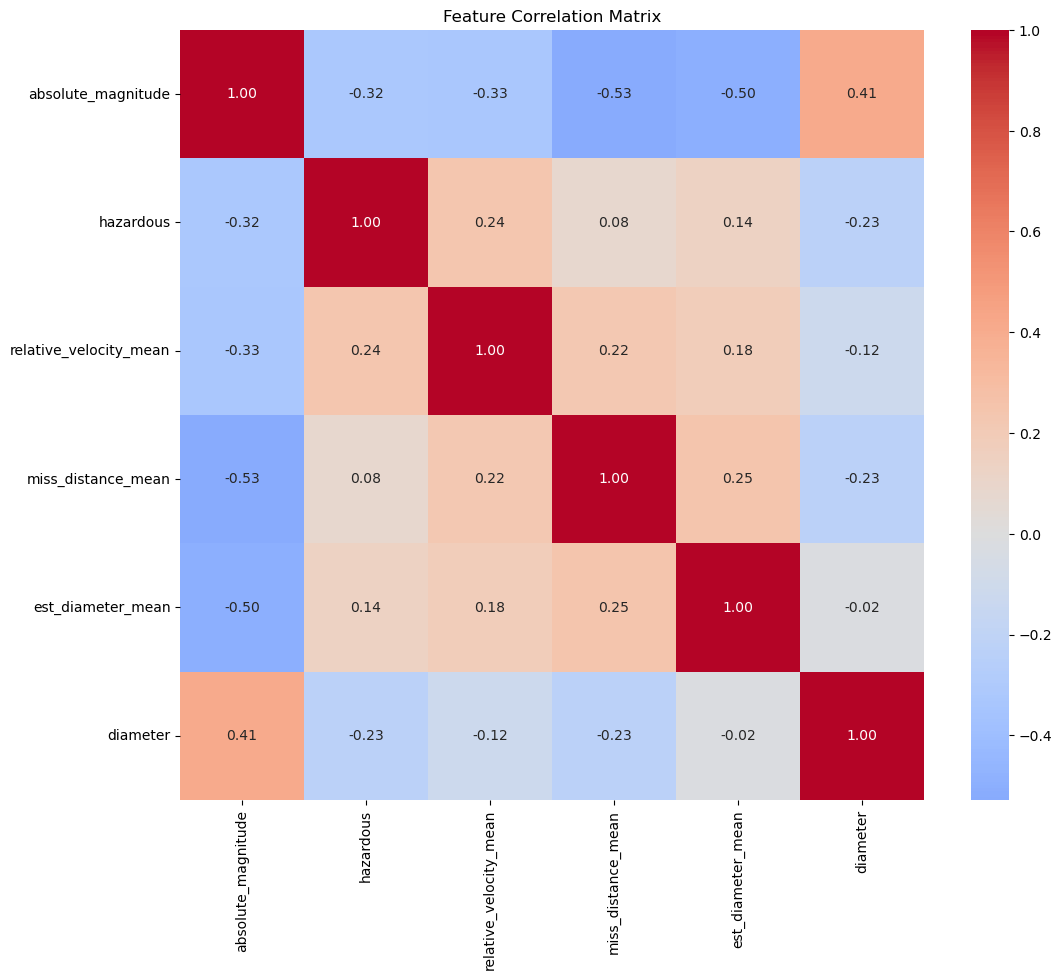

In [ ]:
# Correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(neo.corr(), cmap='coolwarm', center=0, annot=True, fmt='.2f', cbar=True)
plt.title("Feature Correlation Matrix")
plt.show()

In [9]:
# Extracting rows where diameter is present
dff = neo[neo['diameter'].notna()]
print(dff.shape)

(27098, 6)


In [10]:
# Get the counts of the 'hazardous' column
hazardous_counts = dff['hazardous'].value_counts()
print(hazardous_counts)
# Highly imbalanced class - about 92.4% vs 7.6% split

hazardous
0    25027
1     2071
Name: count, dtype: int64


In [11]:
# Features and target
X = dff.drop(columns = ['hazardous'])
y = dff['hazardous']

# Use Stratified Train/Test Split
# Stratified split ensures both sets have the same class ratio (e.g., ~7.6% hazardous in both train and test).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### 🔍 Classification Model

We start with a basic Random Forest Classifier as a baseline. Then continue on to XGBoost, LightBGM and Catboost.

[[4881  125]
 [ 277  137]]
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      5006
           1       0.52      0.33      0.41       414

    accuracy                           0.93      5420
   macro avg       0.73      0.65      0.68      5420
weighted avg       0.91      0.93      0.92      5420



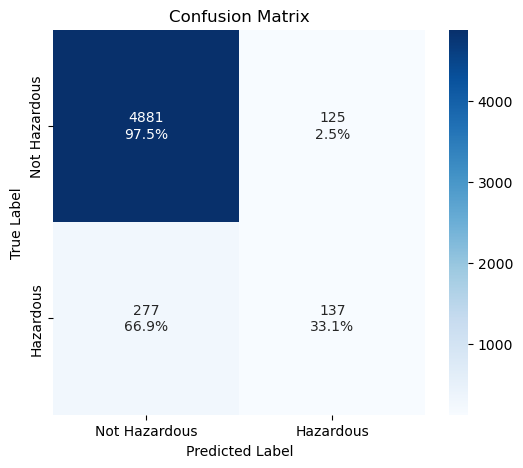

In [12]:
# Random Forest Classifier

# Train a classification model
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)

y_pred = rfc.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

print(classification_report(y_test, y_pred))

# Calculate row-wise percentages
cm_row_sum = cm.sum(axis=1, keepdims=True)
cm_percent = cm / cm_row_sum * 100  # row-wise %

# Create combined label with count and row-wise %
labels = np.array([
    f"{count}\n{percent:.1f}%"
    for count, percent in zip(cm.flatten(), cm_percent.flatten())
]).reshape(cm.shape)

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues',
            xticklabels=['Not Hazardous', 'Hazardous'],
            yticklabels=['Not Hazardous', 'Hazardous'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


#### Applying SMOTE due to high imbalance of target variable

In [13]:
# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

print(f"Original training set shape: {X_train.shape}, {y_train.shape}")
print(f"Resampled training set shape: {X_resampled.shape}, {y_resampled.shape}")

Original training set shape: (21678, 5), (21678,)
Resampled training set shape: (40042, 5), (40042,)


In [14]:
# Random forest classifier

# Train your model on the resampled data
rfc.fit(X_resampled, y_resampled)

# Predict probabilities on the original test set
y_probs = rfc.predict_proba(X_test)[:, 1]

# Choose a LOWER threshold to reduce false negatives (improve recall)
threshold = 0.2  # example, you can try 0.2, 0.25, 0.3, etc.

# Convert probabilities to class labels based on the threshold
y_pred = (y_probs >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)

# Evaluate
print("\n=== Random Forest ===")
print(cm)
print(classification_report(y_test, y_pred, target_names=['Not Hazardous', 'Hazardous']))


=== Random Forest ===
[[4206  800]
 [  39  375]]
               precision    recall  f1-score   support

Not Hazardous       0.99      0.84      0.91      5006
    Hazardous       0.32      0.91      0.47       414

     accuracy                           0.85      5420
    macro avg       0.65      0.87      0.69      5420
 weighted avg       0.94      0.85      0.88      5420



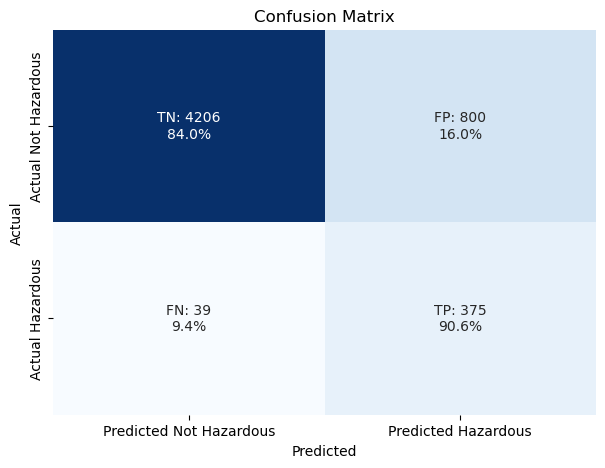

In [15]:
# Plotting confusion matrix
cm_row_sum = cm.sum(axis=1, keepdims=True)
cm_percent_row = cm / cm_row_sum * 100

labels = np.array([
    [f'TN: {cm[0,0]}\n{cm_percent_row[0,0]:.1f}%',
     f'FP: {cm[0,1]}\n{cm_percent_row[0,1]:.1f}%'],
    [f'FN: {cm[1,0]}\n{cm_percent_row[1,0]:.1f}%',
     f'TP: {cm[1,1]}\n{cm_percent_row[1,1]:.1f}%']
])

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Predicted Not Hazardous', 'Predicted Hazardous'],
            yticklabels=['Actual Not Hazardous', 'Actual Hazardous'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [16]:
# XGBoost model

xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
)

# Train on resampled data
xgb.fit(X_resampled, y_resampled)

# Predict probabilities on the original test set (probabilities for class 1)
y_probs_xgb = xgb.predict_proba(X_test)[:, 1]

# Set a threshold (e.g., 0.2)
threshold = 0.2
y_pred_xgb = (y_probs_xgb >= threshold).astype(int)

cm_xg = confusion_matrix(y_test, y_pred_xgb)

# Evaluate
print("\n=== XGBoost ===")
print(cm_xg)
print(classification_report(y_test, y_pred_xgb, digits=4))


=== XGBoost ===
[[4116  890]
 [  23  391]]
              precision    recall  f1-score   support

           0     0.9944    0.8222    0.9002      5006
           1     0.3052    0.9444    0.4614       414

    accuracy                         0.8315      5420
   macro avg     0.6498    0.8833    0.6808      5420
weighted avg     0.9418    0.8315    0.8666      5420



c:\Users\aj20j\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [18:38:01] WARNING: C:\b\abs_52v3kadn8m\croot\xgboost-split_1748343554494\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


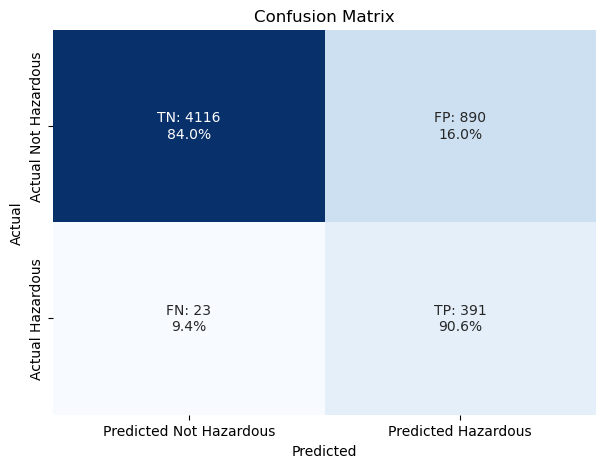

In [18]:
# Plotting confusion matrix
cm_row_sum = cm_xg.sum(axis=1, keepdims=True)
cm_percent_row = cm / cm_row_sum * 100

labels = np.array([
    [f'TN: {cm_xg[0,0]}\n{cm_percent_row[0,0]:.1f}%',
     f'FP: {cm_xg[0,1]}\n{cm_percent_row[0,1]:.1f}%'],
    [f'FN: {cm_xg[1,0]}\n{cm_percent_row[1,0]:.1f}%',
     f'TP: {cm_xg[1,1]}\n{cm_percent_row[1,1]:.1f}%']
])

plt.figure(figsize=(7,5))
sns.heatmap(cm_xg, annot=labels, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Predicted Not Hazardous', 'Predicted Hazardous'],
            yticklabels=['Actual Not Hazardous', 'Actual Hazardous'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [19]:
# LightGBM model

lgbm = LGBMClassifier(
    random_state=42,
    is_unbalance=True
)

# Train on resampled data
lgbm.fit(X_resampled, y_resampled)

# Predict probabilities on the original test set (probabilities for class 1)
y_probs_lgbm = lgbm.predict_proba(X_test)[:, 1]

# Set a threshold (e.g., 0.2)
threshold = 0.2
y_pred_lgbm = (y_probs_lgbm >= threshold).astype(int)

cm_lg = confusion_matrix(y_test, y_pred_lgbm)

# Evaluate
print("\n=== LightGBM ===")
print(cm_lg)
print(classification_report(y_test, y_pred_lgbm, digits=4))

c:\Users\aj20j\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\aj20j\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\aj20j\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\aj20j\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\aj20j\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

[LightGBM] [Info] Number of positive: 20021, number of negative: 20021
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000637 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 40042, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

=== LightGBM ===
[[4206  800]
 [  31  383]]
              precision    recall  f1-score   support

           0     0.9927    0.8402    0.9101      5006
           1     0.3238    0.9251    0.4796       414

    accuracy                         0.8467      5420
   macro avg     0.6582    0.8827    0.6949      5420
weighted avg     0.9416    0.8467    0.8772      5420



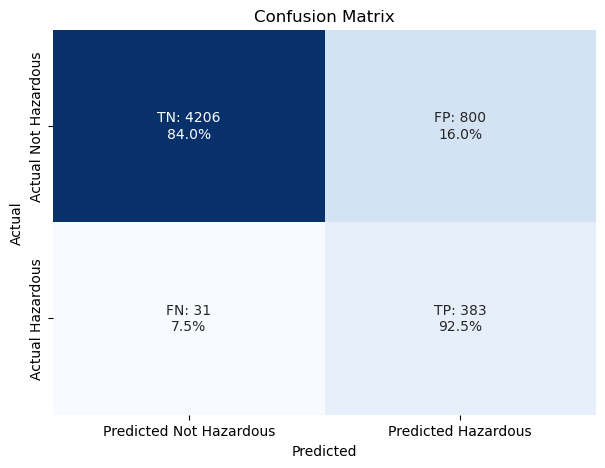

In [20]:
# Plotting confusion matrix
cm_row_sum = cm_lg.sum(axis=1, keepdims=True)
cm_percent_row = cm_lg / cm_row_sum * 100

labels = np.array([
    [f'TN: {cm_lg[0,0]}\n{cm_percent_row[0,0]:.1f}%',
     f'FP: {cm_lg[0,1]}\n{cm_percent_row[0,1]:.1f}%'],
    [f'FN: {cm_lg[1,0]}\n{cm_percent_row[1,0]:.1f}%',
     f'TP: {cm_lg[1,1]}\n{cm_percent_row[1,1]:.1f}%']
])

plt.figure(figsize=(7,5))
sns.heatmap(cm_lg, annot=labels, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Predicted Not Hazardous', 'Predicted Hazardous'],
            yticklabels=['Actual Not Hazardous', 'Actual Hazardous'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [21]:
# CatBoost model

cat = CatBoostClassifier(
    random_seed=42,
    verbose=0,
    class_weights=[1, (y_train == 0).sum() / (y_train == 1).sum()]
)

# Train on resampled data
cat.fit(X_resampled, y_resampled)

# Predict probabilities on the original test set (probabilities for class 1)
y_probs_cat = cat.predict_proba(X_test)[:, 1]

# Set a threshold (e.g., 0.2)
threshold = 0.2
y_pred_cat = (y_probs_cat >= threshold).astype(int)

cm_cat = confusion_matrix(y_test, y_pred_cat)

# Evaluate
print("\n=== CatBoost ===")
print(cm_cat)
print(classification_report(y_test, y_pred_cat, digits=4))


=== CatBoost ===
[[3969 1037]
 [   8  406]]
              precision    recall  f1-score   support

           0     0.9980    0.7928    0.8837      5006
           1     0.2814    0.9807    0.4373       414

    accuracy                         0.8072      5420
   macro avg     0.6397    0.8868    0.6605      5420
weighted avg     0.9432    0.8072    0.8496      5420



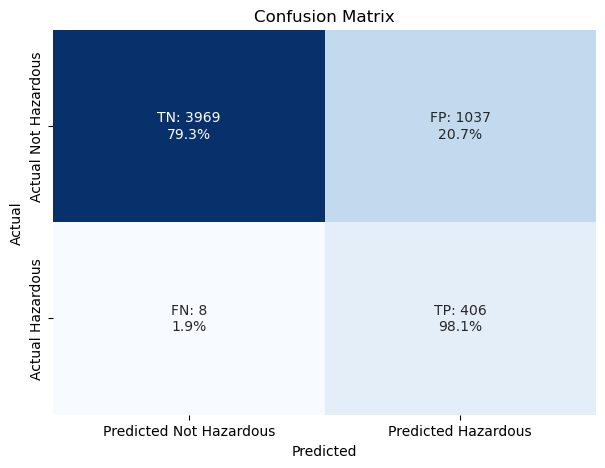

In [22]:
# Plotting confusion matrix
cm_row_sum = cm_cat.sum(axis=1, keepdims=True)
cm_percent_row = cm_cat / cm_row_sum * 100

labels = np.array([
    [f'TN: {cm_cat[0,0]}\n{cm_percent_row[0,0]:.1f}%',
     f'FP: {cm_cat[0,1]}\n{cm_percent_row[0,1]:.1f}%'],
    [f'FN: {cm_cat[1,0]}\n{cm_percent_row[1,0]:.1f}%',
     f'TP: {cm_cat[1,1]}\n{cm_percent_row[1,1]:.1f}%']
])

plt.figure(figsize=(7,5))
sns.heatmap(cm_cat, annot=labels, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Predicted Not Hazardous', 'Predicted Hazardous'],
            yticklabels=['Actual Not Hazardous', 'Actual Hazardous'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### “This model is designed to prioritize recall, since missing a hazardous asteroid is more dangerous than raising a false alarm.”

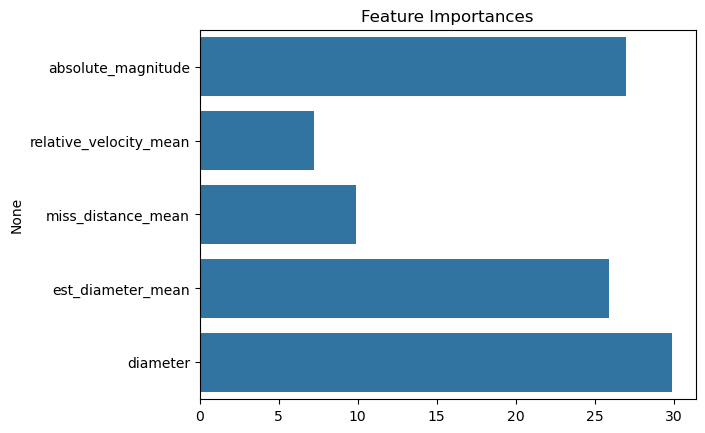

In [23]:
importances = cat.feature_importances_
features = X_train.columns
sns.barplot(x=importances, y=features)
plt.title('Feature Importances')
plt.show()

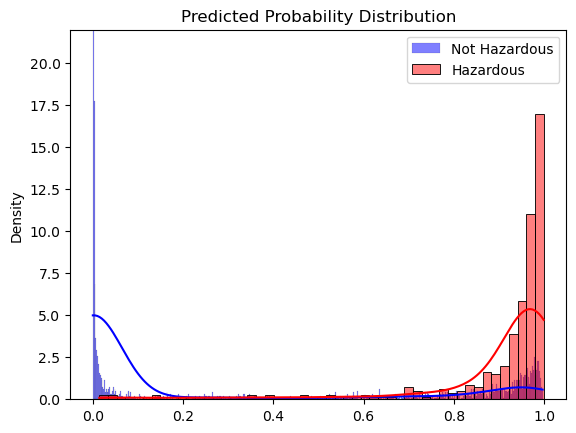

In [24]:
y_proba = cat.predict_proba(X_test)[:,1]
sns.histplot(y_proba[y_test==0], color='blue', label='Not Hazardous', stat='density', kde=True)
sns.histplot(y_proba[y_test==1], color='red', label='Hazardous', stat='density', kde=True)
plt.title('Predicted Probability Distribution')
plt.ylim([0,22])
plt.legend()
plt.show()

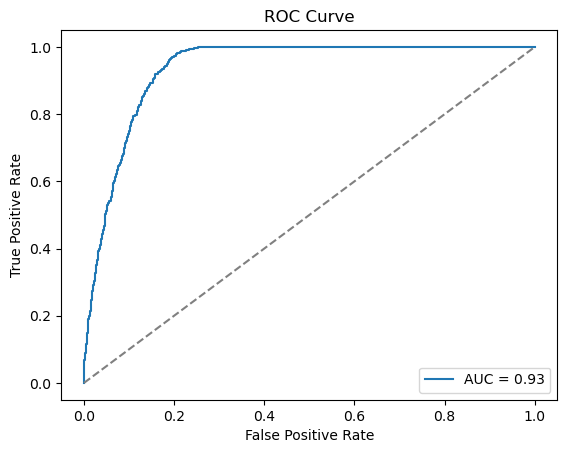

In [25]:
y_proba = cat.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

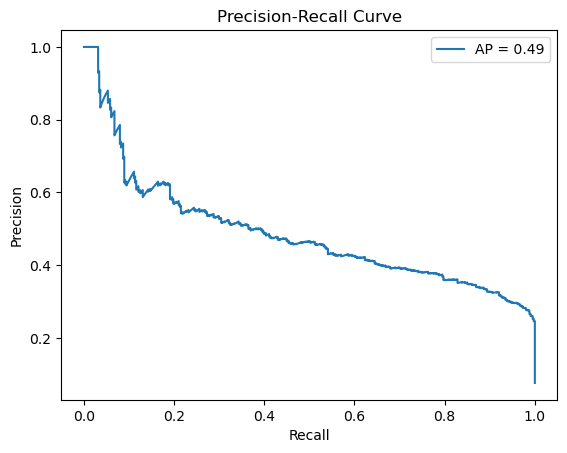

In [26]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

plt.plot(recall, precision, label=f'AP = {ap:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

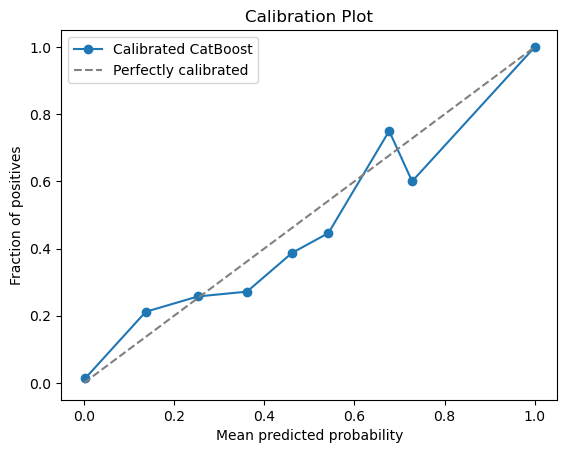

In [27]:
# Plotting calibration

calibrated_cat = CalibratedClassifierCV(cat, method='isotonic', cv='prefit')
calibrated_cat.fit(X_train, y_train)

# New probabilities after calibration
y_proba_cal = calibrated_cat.predict_proba(X_test)[:,1]

# Plot calibration curve again with calibrated probs
prob_true, prob_pred = calibration_curve(y_test, y_proba_cal, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', label='Calibrated CatBoost')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Perfectly calibrated')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Plot')
plt.legend()
plt.show()